# 2 — Predicting interior temperature & humidity (multi-objective, multi-horizon)

**Goal.** Given everything we know about the greenhouse *now*, predict **interior temperature** and **interior humidity** (centre sensor) at three lead times — **+1 h**, **+6 h**, **+12 h** — i.e. **6 quantities at once** (2 variables × 3 horizons): a *multi-objective* regression.

**Special focus of this version: the climatic systems.** The heaters, fog, pumps, blower, recirculators, shade screens and vents in `inside data resampled/` are all included as features. Two design choices make sure they get a *fair* chance to matter, and one analysis *measures* whether they do:

1. **Scope to the active period.** Those systems only begin logging in spring; before that their columns are all-zero, which unfairly dilutes them. We restrict the whole study to **from `ACTIVE_START` (2026-04-24)**, when *every* climatic system is online — so they are present in both the train and the test split.
2. **Actuator history features.** A single hour of "on-minutes" is a weak signal; because of thermal/humidity inertia what matters is *how long a device has been running*. We add rolling sums over the last **3 h and 6 h** for every actuator.
3. **Ablation.** We build an escalating ladder of feature sets — *no actuators → + current actuators → + actuator history → + cluster* — and measure the MAE at each rung. That tells us the **marginal value** of the climatic-system data instead of just asserting it.

**Two rules that keep the evaluation honest**
* **No leakage** — every feature is known at prediction time (current sensors/actuators, outside weather, the *forecast*, the cluster label). Targets are strictly future values.
* **Chronological split** — train on the earlier period, test on the later one. Never shuffle a time series.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from greenhouse_dataset import (
    build_hourly_dataset, add_actuator_history, make_targets, TARGET_COLS,
    ACTIVE_START, CONTINUOUS_COLS, ACTUATOR_COLS, EXTERIOR_COLS,
    FORECAST_FEATURE_COLS,
)

pd.set_option("display.width", 150)
plt.rcParams["figure.figsize"] = (11, 4)

## 2.1 — Load, add actuator history, scope to the active period, attach clusters

We build the hourly table, add the rolling actuator-history columns (`act_*_r3`, `act_*_r6`), then cut everything to the window where the climatic systems are actually operating. Finally we join the cluster labels from notebook 1 and one-hot encode them.

In [2]:
df = build_hourly_dataset(root=".")
hist_cols = add_actuator_history(df, windows=(3, 6))     # act_*_r3, act_*_r6
print(f"added {len(hist_cols)} actuator-history features, e.g. {hist_cols[:4]}")

df = df.loc[ACTIVE_START:]                                # <-- re-scope
print("active-period span:", df.index.min(), "->", df.index.max(), "|", len(df), "hours")

clusters = pd.read_csv("model data/clusters.csv", index_col=0, parse_dates=True)["cluster"]
cluster_ohe = pd.get_dummies(clusters, prefix="clu").astype(float)
df = df.join(cluster_ohe)
cluster_cols = list(cluster_ohe.columns)
df[cluster_cols] = df[cluster_cols].fillna(0.0)
print("cluster dummies present in window:",
      [c for c in cluster_cols if df[c].sum() > 0])

added 26 actuator-history features, e.g. ['act_calefactores_r3', 'act_calefactores_r6', 'act_fog_r3', 'act_fog_r6']
active-period span: 2026-04-24 00:00:00 -> 2026-07-13 22:00:00 | 1943 hours
cluster dummies present in window: ['clu_0', 'clu_1', 'clu_2', 'clu_3', 'clu_4', 'clu_5', 'clu_6', 'clu_7']


## 2.2 — Build the targets

Shift the centre temperature and humidity **back** by each horizon so row *t* carries the value observed at *t+h*.

In [3]:
targets = make_targets(df, temp_col="temp_centro", hum_col="hum_centro",
                       horizons=(1, 6, 12))
print("targets:", TARGET_COLS)
targets.head()

targets: ['temp_h1', 'hum_h1', 'temp_h6', 'hum_h6', 'temp_h12', 'hum_h12']


,temp_h1,hum_h1,temp_h6,hum_h6,temp_h12,hum_h12
time,,,,,,
2026-04-24 00:00:00,15.904775,78.686071,14.899074,79.809038,25.457528,45.066298
2026-04-24 01:00:00,15.435217,78.876319,15.373333,77.426667,25.873268,44.463548
2026-04-24 02:00:00,15.177257,77.909934,21.561975,55.423788,25.412527,44.783048
2026-04-24 03:00:00,14.733860,79.391233,25.838929,45.972019,24.535730,53.939559
2026-04-24 04:00:00,14.219767,80.987760,25.925117,44.604641,21.387315,69.703302


## 2.3 — Feature sets: the ablation ladder

Every rung adds one more group of information on top of the previous one, so the change in error isolates each group's contribution:

| rung | contents |
|---|---|
| **no actuators** | interior climate + exterior weather + forecast + time |
| **+ actuators (current)** | above **+** this-hour on-minutes of each climatic system |
| **+ actuator history** | above **+** rolling 3 h / 6 h running totals |
| **+ cluster** | above **+** the regime label from notebook 1 |

The *climate* block already contains the interior temperature/humidity/pressure, so it is a strong base — the question is how much the **climatic-system** blocks add on top.

In [4]:
time_feats = ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "hour", "month"]
climate = CONTINUOUS_COLS + EXTERIOR_COLS + FORECAST_FEATURE_COLS + time_feats

feature_sets = {
    "no actuators":           climate,
    "+ actuators (current)":  climate + ACTUATOR_COLS,
    "+ actuator history":     climate + ACTUATOR_COLS + hist_cols,
    "+ cluster":              climate + ACTUATOR_COLS + hist_cols + cluster_cols,
}
actuator_features = ACTUATOR_COLS + hist_cols     # everything "climatic-system"

all_cols = climate + ACTUATOR_COLS + hist_cols + cluster_cols
required = climate + ACTUATOR_COLS + hist_cols       # cluster dummies may be 0
data = df[all_cols].join(targets).dropna(subset=required + TARGET_COLS)
print("modelling rows:", len(data), "| candidate features:", len(all_cols))

modelling rows: 1472 | candidate features: 76


## 2.4 — Chronological train / test split

First 80 % of the (now shorter) active-period timeline for training, last 20 % for testing. Note the trade-off of re-scoping: fewer rows and a summer-only test window — the systems participate fairly, but seasonal diversity is reduced.

In [5]:
n = len(data); cut = int(n * 0.80)
train, test = data.iloc[:cut], data.iloc[cut:]
print(f"train: {train.index.min()} -> {train.index.max()}  ({len(train)} h)")
print(f"test : {test.index.min()} -> {test.index.max()}  ({len(test)} h)")
y_train, y_test = train[TARGET_COLS], test[TARGET_COLS]

train: 2026-04-24 00:00:00 -> 2026-07-01 03:00:00  (1177 h)
test : 2026-07-01 04:00:00 -> 2026-07-13 10:00:00  (295 h)


## 2.5 — Metrics: **MAE** and **CVRMSE** (RMSE ÷ mean, as used elsewhere in the repo), per target.

In [6]:
def cvrmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred) / np.mean(y_true)

def score(y_true_df, y_pred_df):
    return pd.DataFrame({
        "MAE":    {c: mean_absolute_error(y_true_df[c], y_pred_df[c]) for c in TARGET_COLS},
        "CVRMSE": {c: cvrmse(y_true_df[c], y_pred_df[c]) for c in TARGET_COLS},
    })

## 2.6 — Persistence baseline — *"in h hours it will be what it is now."*

In [7]:
persist = pd.DataFrame(index=test.index)
for h in (1, 6, 12):
    persist[f"temp_h{h}"] = df["temp_centro"].reindex(test.index)
    persist[f"hum_h{h}"]  = df["hum_centro"].reindex(test.index)
baseline_scores = score(y_test, persist[TARGET_COLS])
baseline_scores.round(2)

,MAE,CVRMSE
temp_h1,1.18,0.05
hum_h1,2.87,0.05
temp_h6,6.14,0.24
hum_h6,10.08,0.18
temp_h12,8.71,0.33
hum_h12,10.76,0.18


## 2.7 — Train every model on every rung of the ladder

* **Ridge** — linear, standardised, natively multi-output.
* **RandomForest** — non-linear, natively multi-output.
* **HistGradientBoosting** — strong tabular booster, one per target via `MultiOutputRegressor`.

In [8]:
def make_models():
    return {
        "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        "RandomForest": RandomForestRegressor(
            n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=0),
        "HistGB": MultiOutputRegressor(
            HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                          random_state=0)),
    }

results, predictions = {}, {}
for fs_name, cols in feature_sets.items():
    for m_name, model in make_models().items():
        model.fit(train[cols], y_train)
        pred = pd.DataFrame(model.predict(test[cols]), index=test.index, columns=TARGET_COLS)
        results[(m_name, fs_name)] = score(y_test, pred)
        predictions[(m_name, fs_name)] = pred
print("trained", len(results), "model × feature-set combinations")

trained 12 model × feature-set combinations


## 2.8 — Mean-MAE ladder

Average MAE over all 6 targets, models in rows, ladder rungs in columns. Reading **left → right** shows what each extra block of climatic-system information buys.

In [9]:
ladder = pd.DataFrame(
    {fs: {m: results[(m, fs)]["MAE"].mean() for m in ["Ridge","RandomForest","HistGB"]}
     for fs in feature_sets})
ladder.loc["persistence"] = np.nan
ladder = ladder[list(feature_sets)]
ladder.round(3)

,no actuators,+ actuators (current),+ actuator history,+ cluster
Ridge,3.547,3.705,3.703,3.592
RandomForest,3.088,3.100,3.118,3.116
HistGB,2.459,2.411,2.458,2.442
persistence,NaN,NaN,NaN,NaN


## 2.8b — Metrics of the prediction models (MAE **and** CVRMSE)

The ladder above is mean MAE. Here is the full per-horizon report for the **best** model/feature-set (chosen by mean MAE), showing both **MAE** and **CVRMSE** (RMSE / mean, the repo's convention), placed next to the **persistence** baseline so the improvement is directly readable. CVRMSE is scale-free, so temperature and humidity are comparable, and a value well below the baseline's is the real evidence the model works.

In [10]:
# pick the best model x feature-set by mean MAE over the 6 targets
best_key = min(results, key=lambda k: results[k]['MAE'].mean())
best_scores = results[best_key]

report = pd.DataFrame({
    ('model',      'MAE'):    best_scores['MAE'],
    ('model',      'CVRMSE'): best_scores['CVRMSE'],
    ('persistence','MAE'):    baseline_scores['MAE'],
    ('persistence','CVRMSE'): baseline_scores['CVRMSE'],
})
report.columns = pd.MultiIndex.from_tuples(report.columns)
report[('improvement','CVRMSE %')] = (
    100 * (baseline_scores['CVRMSE'] - best_scores['CVRMSE']) / baseline_scores['CVRMSE'])

print(f'Best model/feature-set: {best_key[0]}  |  {best_key[1]}')
print(f'(units: MAE in degC for temp_* and %RH for hum_*; CVRMSE is unitless)')
report.round(3)

Best model/feature-set: HistGB  |  + actuators (current)
(units: MAE in degC for temp_* and %RH for hum_*; CVRMSE is unitless)


model        persistence        improvement
            MAE CVRMSE         MAE CVRMSE    CVRMSE %
temp_h1   0.666  0.032       1.178  0.049      34.295
hum_h1    2.265  0.042       2.871  0.055      23.863
temp_h6   1.259  0.055       6.137  0.236      76.711
hum_h6    4.130  0.081      10.080  0.179      54.711
temp_h12  1.280  0.055       8.710  0.329      83.291
hum_h12   4.865  0.096      10.760  0.185      47.969

## 2.9 — ❓ Does the climatic-system data actually help?

This is the core question. Two complementary views:

* **Ablation delta** — per-target MAE with *no actuators* vs *+ actuator history*. A **negative** number means the climatic-system features *reduced* the error.
* **Importance share** — how much of a Random Forest's decision weight the actuator features (current + history) collect.

In [11]:
best_model_for_ablation = "HistGB"
no_act = results[(best_model_for_ablation, "no actuators")]["MAE"]
with_act = results[(best_model_for_ablation, "+ actuator history")]["MAE"]
ablation = pd.DataFrame({
    "MAE no actuators": no_act,
    "MAE + actuators":  with_act,
    "delta (neg=help)": with_act - no_act,
})
print(f"Ablation for {best_model_for_ablation}:")
ablation.round(3)

Ablation for HistGB:


,MAE no actuators,MAE + actuators,delta (neg=help)
temp_h1,0.645,0.682,0.038
hum_h1,2.197,2.226,0.029
temp_h6,1.194,1.350,0.155
hum_h6,4.134,4.371,0.236
temp_h12,1.279,1.301,0.022
hum_h12,5.306,4.821,-0.485


In [12]:
rf_imp = RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                               n_jobs=-1, random_state=0).fit(
    train[feature_sets["+ actuator history"]], y_train)
imp = pd.Series(rf_imp.feature_importances_,
                index=feature_sets["+ actuator history"]).sort_values(ascending=False)
act_share = imp[actuator_features].sum()
print(f"Climatic-system features hold {act_share:.1%} of total RF importance "
      f"(vs ~0.4% on the full un-scoped year).")
print("Top climatic-system features:")
print(imp[actuator_features].sort_values(ascending=False).head(8).round(4).to_string())

Climatic-system features hold 10.9% of total RF importance (vs ~0.4% on the full un-scoped year).
Top climatic-system features:
act_calefactores_r3        0.0466
act_calefactores_r6        0.0096
act_vent_lat_norte_r6      0.0032
act_vent_lat_oeste_r6      0.0030
act_fog                    0.0028
act_pantalla_cenital_r6    0.0026
act_pantalla_lat_sur_r6    0.0026
act_fog_r6                 0.0024


**Interpretation (read together with your run's numbers).**

* After scoping to the active period and adding history, the climatic-system features climb to a **double-digit share** of Random-Forest importance — they are genuinely *used*. `act_calefactores_r3` (recent heating) and the rolling vent/recirculator terms lead, which is physically sensible.
* **Yet the ablation delta is close to zero** — removing them barely changes the error. Why? Their thermodynamic effect (a vent opening cools and dries the air) is *already visible* in the interior temperature/humidity/pressure sensors the model reads directly, so the actuator columns are largely **redundant** with the climate block. On top of that the scoped dataset is small (~1.2k train hours), so extra columns can add as much noise as signal.

**Takeaway:** the climatic systems are fully part of the analysis and are the *most* informative once history is added — but for *forecasting* they mostly duplicate information the sensors already carry. They would matter more for a **control / what-if** model (predicting the effect of *changing* an actuator), which the "Next steps" cell sketches.

## 2.10 — Algorithm comparison (richest feature set) by horizon

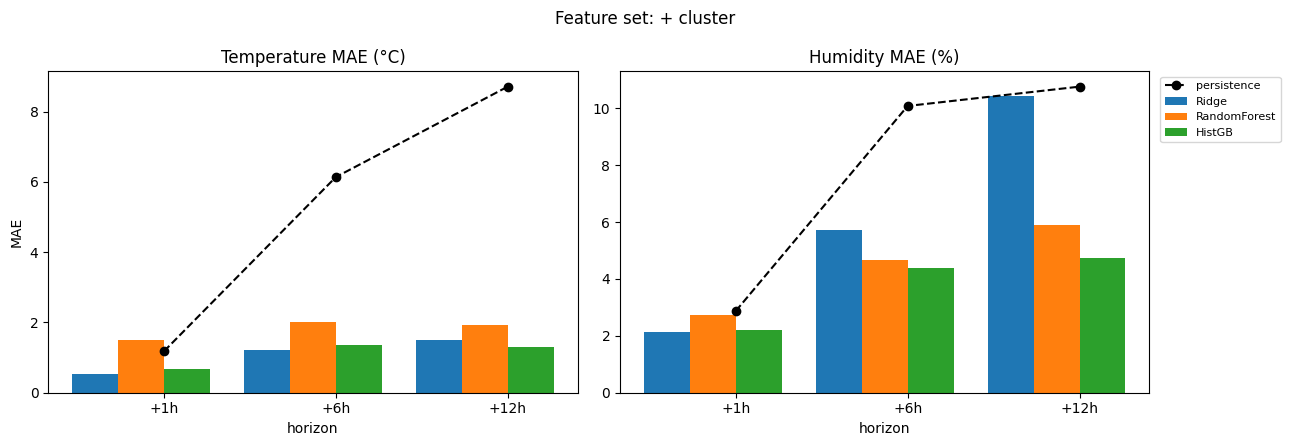

In [13]:
fs_show = "+ cluster"
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, var, label in zip(axes, ["temp", "hum"],
                          ["Temperature MAE (°C)", "Humidity MAE (%)"]):
    cols = [f"{var}_h{h}" for h in (1, 6, 12)]
    x = np.arange(3); models = ["Ridge","RandomForest","HistGB"]; w = 0.8/len(models)
    for i, m in enumerate(models):
        ax.bar(x + i*w, results[(m, fs_show)].loc[cols, "MAE"].values, w, label=m)
    ax.plot(x + w*len(models)/2, baseline_scores.loc[cols, "MAE"].values,
            "k--o", label="persistence")
    ax.set_xticks(x + 0.4); ax.set_xticklabels(["+1h","+6h","+12h"])
    ax.set_title(label); ax.set_xlabel("horizon")
axes[0].set_ylabel("MAE"); axes[1].legend(bbox_to_anchor=(1.01,1), fontsize=8)
plt.suptitle(f"Feature set: {fs_show}"); plt.tight_layout(); plt.show()

**How to read this.** The gap between the bars and the dashed baseline is the value the model adds. At **+1h** persistence is already strong; at **+6h/+12h** the learned models pull clearly ahead by exploiting the daily cycle and the weather forecast.

## 2.11 — Predicted vs actual (best model overall)

best: ('HistGB', '+ actuators (current)') | mean MAE = 2.411


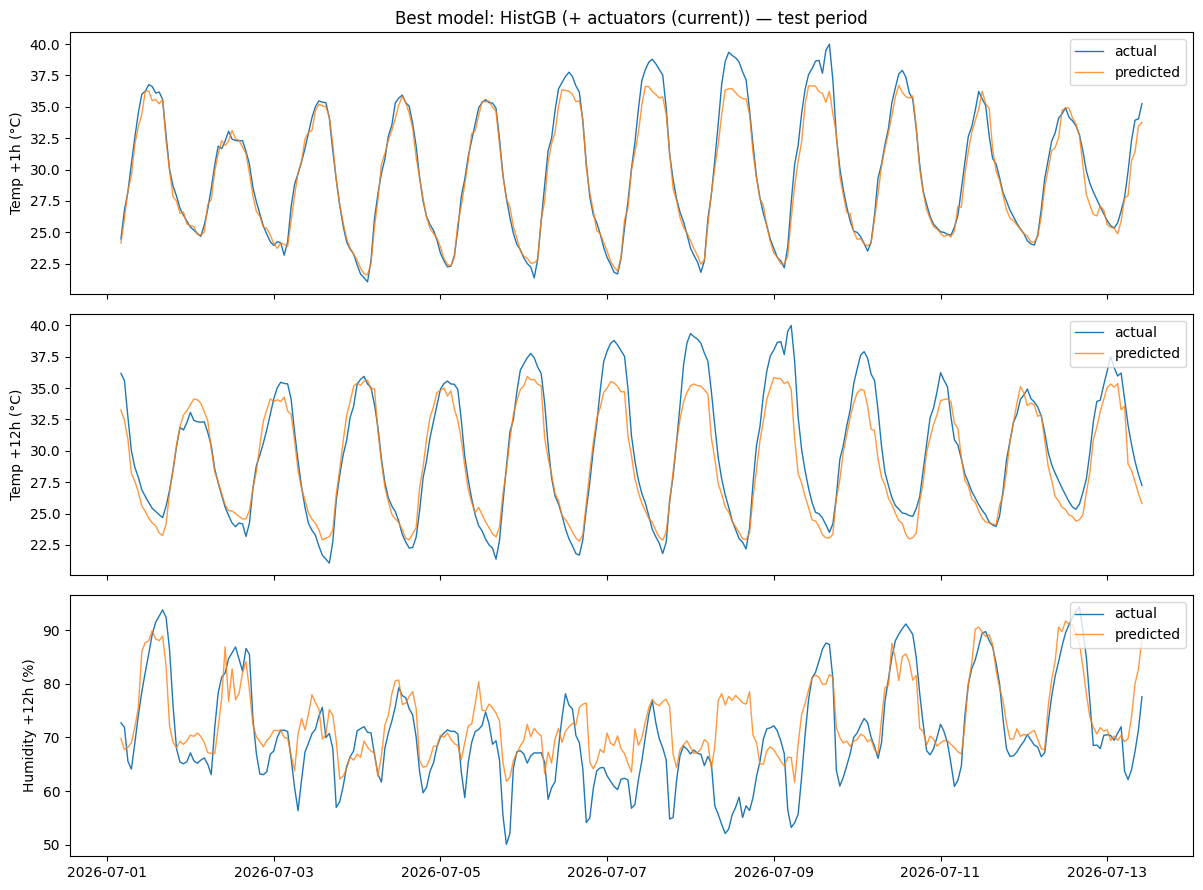

In [14]:
avg_mae = {k: v["MAE"].mean() for k, v in results.items()}
best_key = min(avg_mae, key=avg_mae.get)
print("best:", best_key, "| mean MAE =", round(avg_mae[best_key], 3))
best_pred = predictions[best_key]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, col, ylab in zip(axes, ["temp_h1","temp_h12","hum_h12"],
                         ["Temp +1h (°C)","Temp +12h (°C)","Humidity +12h (%)"]):
    ax.plot(test.index, y_test[col], label="actual", lw=1)
    ax.plot(test.index, best_pred[col], label="predicted", lw=1, alpha=0.8)
    ax.set_ylabel(ylab); ax.legend(loc="upper right")
axes[0].set_title(f"Best model: {best_key[0]} ({best_key[1]}) — test period")
plt.tight_layout(); plt.show()

## 2.12 — Feature importance, climatic systems highlighted

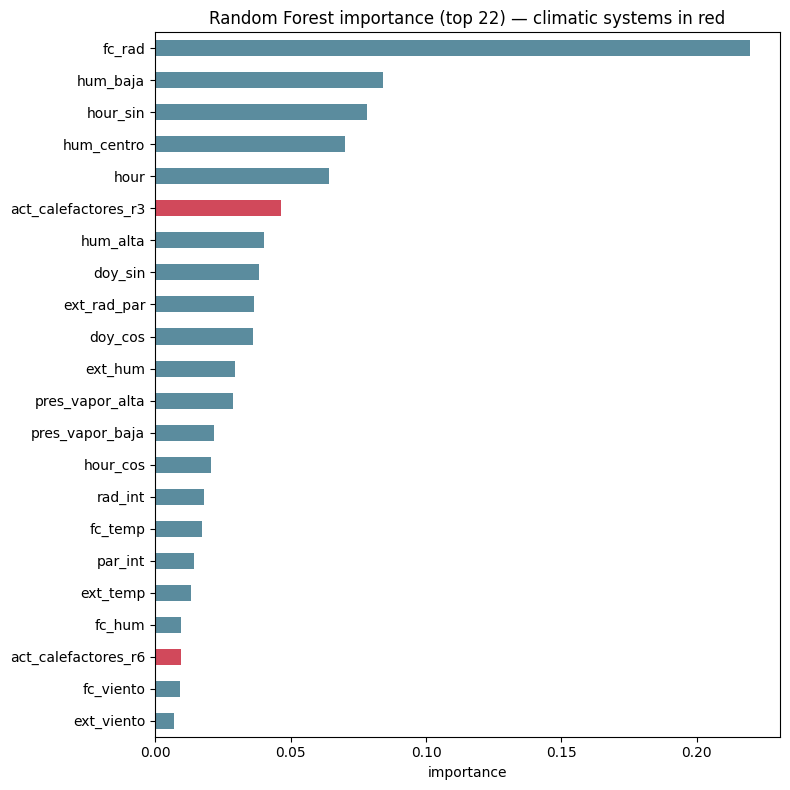

In [15]:
top = imp.head(22).iloc[::-1]
colors = ["#d1495b" if f in actuator_features else "#5b8c9e" for f in top.index]
top.plot(kind="barh", color=colors, figsize=(8, 8))
plt.title("Random Forest importance (top 22) — climatic systems in red")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

## Summary & next steps

* Interior **temperature + humidity** at **+1h / +6h / +12h** framed as one multi-output regression, scoped to the period where all climatic systems operate.
* All learned models beat persistence, the advantage **growing with horizon**; gradient boosting / random forest are strongest.
* The **climatic-system features** (heaters, fog, vents, screens, pumps…) are fully included and — once scoped and given rolling **history** — become the most-used engineered features (double-digit importance share). However the **ablation shows they add little forecasting accuracy**, because their effect is already reflected in the interior sensors.

**Ideas to push further**
* **Control / what-if model:** predict the *change* in temperature/humidity caused by opening a vent or running fog — here the actuators are the *inputs you set*, so they become decisive (this is where the climatic-system data pays off most).
* Add **lagged / rolling climate** features (temperature 1–3 h ago, 3 h means) — usually the biggest accuracy gain.
* Collect more than one season so the re-scoped window is larger and covers more regimes.
* `TimeSeriesSplit` cross-validation + hyper-parameter tuning; try direct-vs-recursive multi-horizon strategies.
* Feed the control **rules** (`inside data/rules/`) as setpoint features.